#Reglas de comportamiento como Autómata Celular
Vecindad: los demás miembros del hogar presentes en el mismo espacio/horario.
###El hogar

*   Si la cocina o la sala están desordenadas cuando llego, tiendo a organizar antes de sentarme a trabajar;
si están ordenadas, las dejo así. (regla de mantenimiento del estado colectivo)
*   Si alguien de la casa está durmiendo o estudiando, bajo el ritmo de mis actividades (menos ruido, luces
bajas) en las celdas vecinas a esa habitación. (regla de vecindad local, tipo vecindad de von Neumann:
solo afecta a quien está físicamente cerca)
*   A la hora de comer, mi horario se sincroniza con el de la mayoría de los presentes (paralelismo social:
todos actualizamos el estado "comiendo" casi al mismo tiempo).
###La universidad


*   Vecindad: compañeros de salón, del grupo de trabajo, del pasillo o de la biblioteca.
*   Si la mayoría de compañeros de un grupo de trabajo llega temprano a una reunión, yo también llego
temprano la siguiente vez; si la norma social del grupo es llegar con 5-10 min de tolerancia, ajusto mi
comportamiento a esa norma implícita (igual que el ejemplo de la vecindad y sus costumbres comunes
del texto).
*   En la biblioteca, si las mesas cercanas están en silencio, mantengo silencio; si el ambiente es de trabajo
colaborativo en voz baja, hablo en voz baja para coordinar. (regla local de nivel de ruido)
*   Reglas explícitas: reglamento estudiantil, horarios de clase, código de honor en exámenes, estas actúan
como la función de transición "oficial" que no depende de la vecindad sino que es igual para todas las
células (homogeneidad).
###El transporte (TransMilenio)
*   Vecindad: los pasajeros inmediatamente al lado, adelante y atrás en el bus o en la fila.
*   Si el bus va lleno y una persona se corre hacia el fondo, los pasajeros detrás de ella también avanzan
para dejar subir a más gente en la siguiente estación (regla de "correrse hacia el fondo", una especie de
difusión local de personas, igual que en la ola de estadio que menciona el documento).
*   Si alguien cede el puesto a una persona mayor o con niños, aumenta la probabilidad de que otro
pasajero cercano haga lo mismo en la siguiente oportunidad (efecto de imitación / contagio de
comportamiento prosocial).
*   En la fila de acceso, si todos hacen fila ordenada, yo hago fila; si el flujo se desordena (hora pico), mi
comportamiento también se ajusta al de la mayoría inmediata para poder abordar (la regla "local"
termina dominando sobre la norma general cuando hay saturación del sistema).

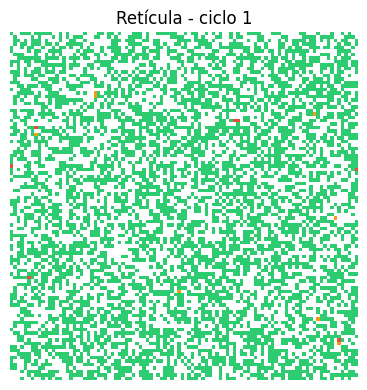

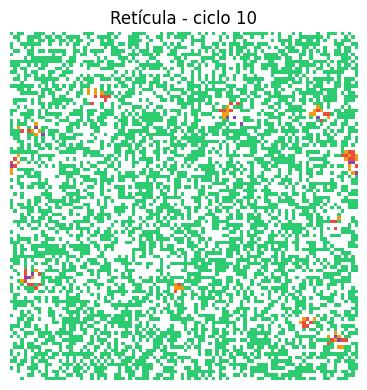

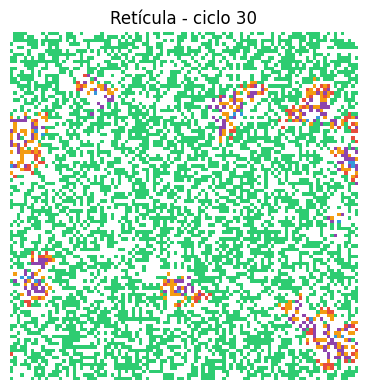

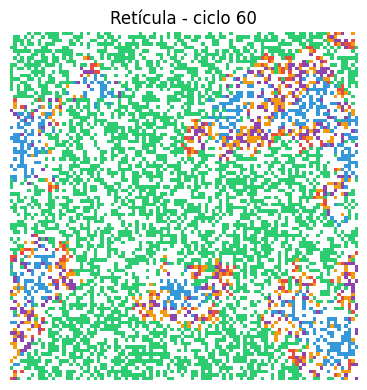

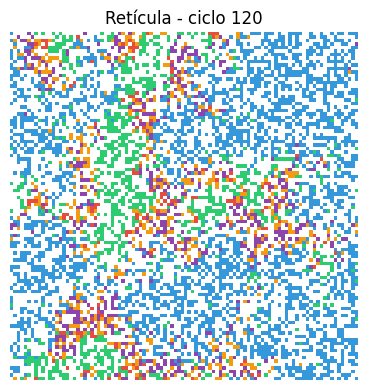

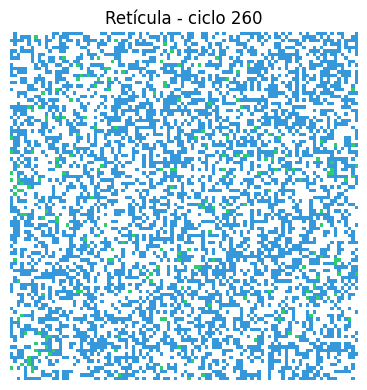

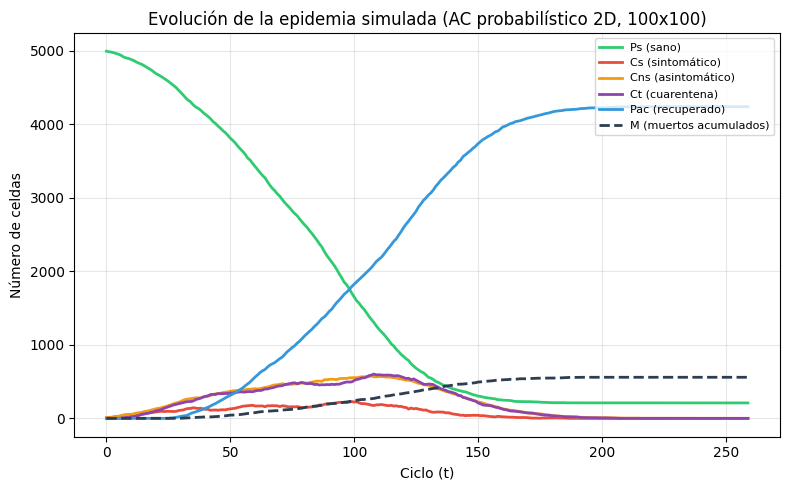

================ RESULTADOS PUNTO 2 ================
Pico de casos activos (Cs+Cns+Ct): 1347 celdas, en el ciclo 111
La población se estabiliza aprox. en el ciclo: 179
Estado final (ciclo 260):
  Np (vacío)            :  5549
  Ps (sano)             :   210
  Cs (sintomático)      :     0
  Cns (asintomático)    :     0
  Ct (cuarentena)       :     0
  Pac (recuperado)      :  4241
  M (muertos acumulados):   559


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

rng = np.random.default_rng(42)

# ---------------------------------------------------------------
# Estados (codificados como enteros para trabajar con arrays numpy)
NP, PS, CS, CNS, CT, PAC = 0, 1, 2, 3, 4, 5
NOMBRES = {NP: "Np (vacío)", PS: "Ps (sano)", CS: "Cs (sintomático)",
           CNS: "Cns (asintomático)", CT: "Ct (cuarentena)", PAC: "Pac (recuperado)"}

N = 100                 # retícula 100x100 = 10.000 celdas
N_CICLOS = 260

# ---------------------------------------------------------------
# Configuración inicial C0: L -> w
grid = np.zeros((N, N), dtype=np.int8)
idx = rng.choice(N * N, size=5000 + 5 + 5, replace=False)
ps_idx, cs_idx, cns_idx = idx[:5000], idx[5000:5005], idx[5005:5010]
grid.flat[ps_idx] = PS
grid.flat[cs_idx] = CS
grid.flat[cns_idx] = CNS

# Contadores de ciclos internos por celda (para Cs->Ct, Cns->Pac, Ct->Pac/M)
ciclos_estado = np.zeros((N, N), dtype=np.int32)

# ---------------------------------------------------------------
def contar_infectados_vecinos(grid):
    """Cuenta vecinos Cs o Cns (vecindad de Moore, retícula toroidal)."""
    infectado = np.isin(grid, [CS, CNS]).astype(np.int8)
    total = np.zeros_like(infectado, dtype=np.int8)
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            if dy == 0 and dx == 0:
                continue
            total += np.roll(np.roll(infectado, dy, axis=0), dx, axis=1)
    return total


historial = {s: [] for s in NOMBRES}
historial["M"] = []
muertos_acum = 0

for t in range(N_CICLOS):
    nueva = grid.copy()
    nuevo_ciclo = ciclos_estado.copy()

    # --- Regla 1: contagio Ps -> Cs / Cns, según nº de vecinos infectados ---
    vecinos_inf = contar_infectados_vecinos(grid)
    ps_mask = grid == PS
    prob_contagio = np.clip(0.1 * vecinos_inf, 0, 1)          # 0.n de probabilidad de contagiarse
    tira = rng.random((N, N))
    se_contagia = ps_mask & (tira < prob_contagio)
    tipo = rng.random((N, N))
    nueva[se_contagia & (tipo < 0.4)] = CNS                    # 40% asintomático
    nueva[se_contagia & (tipo >= 0.4)] = CS                    # 60% sintomático
    nuevo_ciclo[se_contagia] = 0

    # --- Regla 2: Cs -> Ct tras 7 ciclos ---
    cs_mask = grid == CS
    nuevo_ciclo[cs_mask] += 1
    pasa_ct = cs_mask & (nuevo_ciclo >= 7)
    nueva[pasa_ct] = CT
    nuevo_ciclo[pasa_ct] = 0

    # --- Regla 3: Cns -> Pac tras 30 ciclos ---
    cns_mask = grid == CNS
    nuevo_ciclo[cns_mask] += 1
    pasa_pac = cns_mask & (nuevo_ciclo >= 30)
    nueva[pasa_pac] = PAC
    nuevo_ciclo[pasa_pac] = 0

    # --- Regla 4: Ct -> Pac (80%) o M (20%) tras 20 ciclos ---
    ct_mask = grid == CT
    nuevo_ciclo[ct_mask] += 1
    listo_ct = ct_mask & (nuevo_ciclo >= 20)
    suerte = rng.random((N, N))
    se_recupera = listo_ct & (suerte < 0.8)
    se_muere = listo_ct & (suerte >= 0.8)
    nueva[se_recupera] = PAC
    nuevo_ciclo[se_recupera] = 0
    nueva[se_muere] = NP                       # muere -> sale de la retícula
    nuevo_ciclo[se_muere] = 0
    muertos_acum += int(se_muere.sum())

    grid, ciclos_estado = nueva, nuevo_ciclo

    # --- Movimiento browniano: cada celda ocupada se mueve a N/S/E/O con p=0.25 si está vacía ---
    for _ in range(1):
        direcciones = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        mover = rng.random((N, N)) < 0.25
        ocupada = grid != NP
        candidatos = np.argwhere(mover & ocupada)
        rng.shuffle(candidatos)
        for (y, x) in candidatos:
            dy, dx = direcciones[rng.integers(0, 4)]
            ny, nx = (y + dy) % N, (x + dx) % N
            if grid[ny, nx] == NP:
                grid[ny, nx] = grid[y, x]
                ciclos_estado[ny, nx] = ciclos_estado[y, x]
                grid[y, x] = NP
                ciclos_estado[y, x] = 0

    for s in NOMBRES:
        historial[s].append(int((grid == s).sum()))
    historial["M"].append(muertos_acum)

    if t in (0, 9, 29, 59, 119, 259):
        cmap = mcolors.ListedColormap(["white", "#2ecc71", "#e74c3c", "#f39c12", "#8e44ad", "#3498db"])
        plt.figure(figsize=(4, 4))
        plt.imshow(grid, cmap=cmap, vmin=0, vmax=5)
        plt.title(f"Retícula - ciclo {t+1}")
        plt.axis("off")
        plt.tight_layout()
        # Assuming 'output_dir' is defined elsewhere or not strictly needed for display
        # If output_dir is defined, you can use plt.savefig(f"{output_dir}p2_grid_t{t+1}.png", dpi=130)
        plt.show()
        # plt.close() # Removed to display the plot

# ---------------------------------------------------------------
# Gráfica de evolución de la población por estado
plt.figure(figsize=(8, 5))
colores = {"Ps (sano)": "#2ecc71", "Cs (sintomático)": "#e74c3c", "Cns (asintomático)": "#f39c12",
           "Ct (cuarentena)": "#8e44ad", "Pac (recuperado)": "#3498db", "M": "#2c3e50"}
for s in [PS, CS, CNS, CT, PAC]:
    plt.plot(historial[s], label=NOMBRES[s], linewidth=2, color=colores[NOMBRES[s]])
plt.plot(historial["M"], label="M (muertos acumulados)", linewidth=2, color=colores["M"], linestyle="--")
plt.xlabel("Ciclo (t)")
plt.ylabel("Número de celdas")
plt.title("Evolución de la epidemia simulada (AC probabilístico 2D, 100x100)")
plt.legend(loc="upper right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
# If output_dir is defined, you can use plt.savefig(f"{output_dir}p2_evolucion.png", dpi=150)
plt.show()
# plt.close() # Removed to display the plot

# ---------------------------------------------------------------
# Respuestas a las preguntas del enunciado
activos = np.array(historial[CS]) + np.array(historial[CNS]) + np.array(historial[CT])
# estabilización: primer ciclo desde el cual los activos ya no vuelven a subir de forma relevante
pico = int(np.argmax(activos))
# se considera "estable" cuando los casos activos (Cs+Cns+Ct) caen por debajo del 1% de la
# retícula y se mantienen así durante al menos 15 ciclos consecutivos
umbral = max(5, 0.01 * N * N)
estable_t = None
for t in range(len(activos) - 15):
    if np.all(activos[t:t+15] < umbral):
        estable_t = t
        break

print("================ RESULTADOS PUNTO 2 ================")
print(f"Pico de casos activos (Cs+Cns+Ct): {activos.max()} celdas, en el ciclo {pico+1}")
print(f"La población se estabiliza aprox. en el ciclo: {estable_t+1 if estable_t else 'no se estabilizó en 120 ciclos'}")
print(f"Estado final (ciclo {N_CICLOS}):")
for s in NOMBRES:
    print(f"  {NOMBRES[s]:22s}: {historial[s][-1]:5d}")
print(f"  {'M (muertos acumulados)':22s}: {historial['M'][-1]:5d}")
print("======================================================")

================ RESULTADOS PUNTO 3 ================
Obstáculos (x, y):
[[ 87.50954666 114.7213801 ]
 [102.56856902  47.520719  ]
 [ 55.01662849 112.35534454]
 [ 25.52653046 107.12284184]]
Pasos simulados: 1800
Colisiones detectadas: 0
Encuentros cercanos con obstáculos (episodios de evasión): 20
Activaciones de la regla de seguridad: 106 (5.9% de los pasos)
Distancia mínima robot-obstáculo alcanzada: 8.93 cm (radio robot = 3.0 cm -> SIN CHOQUE)


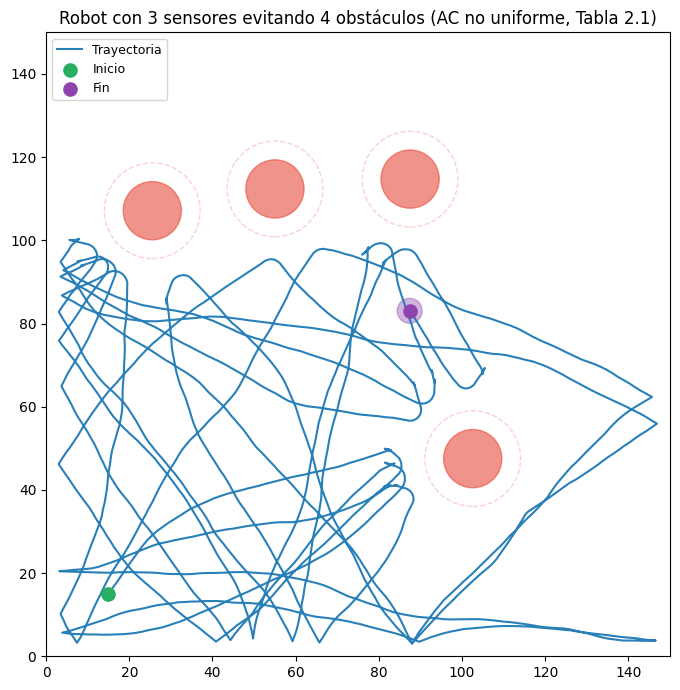

In [10]:
"""
Punto 3 - Robot con tres sensores de distancia (C, D, I) que recorre un espacio 2D
con 4 objetos distribuidos aleatoriamente, sin chocar con ellos.

Se implementa el modelo de AC no uniforme de la sección "En robótica" del documento:
- Células pasivas C (centro), D (derecha), I (izquierda): estado = distancia discretizada
  0: 0-8 cm | 1: 8-16 cm | 2: >16 cm
- Células activas Mi, Md (motor izquierdo / derecho): estado 0=apagado, 1=adelante, 2=atrás
- Regla de transición: la Tabla 2.1 del documento (27 combinaciones de C,D,I)

Se añade una única regla de seguridad adicional (no está en el documento): si el robot
queda a una distancia crítica de un obstáculo, se ignora momentáneamente la tabla y se
gira/retrocede para garantizar que NUNCA choca -- justamente la mejora que el documento
sugiere lograr con Algoritmos Genéticos, aquí resuelta con una regla reactiva simple.
"""

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

# ---------------------------------------------------------------
# Tabla 2.1 del documento: reglas de transición (C, D, I) -> (Mi, Md)
# 0 = apagado, 1 = adelante, 2 = atrás
TABLA_2_1 = {
    (0, 0, 0): (2, 2), (0, 1, 0): (0, 2), (0, 2, 0): (2, 0),
    (0, 0, 1): (2, 0), (0, 1, 1): (2, 0), (0, 2, 1): (2, 0),
    (0, 0, 2): (2, 0), (0, 1, 2): (2, 0), (0, 2, 2): (2, 0),
    (1, 0, 0): (2, 0), (1, 1, 0): (0, 2), (1, 2, 0): (0, 2),
    (1, 0, 1): (2, 0), (1, 1, 1): (1, 0), (1, 2, 1): (1, 0),
    (1, 0, 2): (2, 0), (1, 1, 2): (0, 2), (1, 2, 2): (0, 2),
    (2, 0, 0): (0, 2), (2, 1, 0): (1, 0), (2, 2, 0): (1, 0),
    (2, 0, 1): (0, 1), (2, 1, 1): (1, 0), (2, 2, 1): (1, 1),
    (2, 0, 2): (0, 1), (2, 1, 2): (1, 0), (2, 2, 2): (1, 1),
}
# clave = (C, D, I)  ->  valor = (Mi, Md)

def discretizar(d, r_max=40.0):
    """Distancia (cm) -> estado {0,1,2} según el documento (0-8, 8-16, >16 cm)."""
    if d <= 8:
        return 0
    elif d <= 16:
        return 1
    else:
        return 2

# ---------------------------------------------------------------
# Mundo: 150x150 cm, 4 obstáculos circulares distribuidos aleatoriamente
WORLD = 150.0
N_OBST = 4
R_OBST = 7.0
R_ROBOT = 3.0
DIST_SEGURA = R_OBST + R_ROBOT + 1.5   # margen de seguridad (cm)
SENSOR_MAX = 40.0
SENSOR_ANG = np.radians(40)            # separación angular de I y D respecto a C

inicio = np.array([15.0, 15.0])
obstaculos = []
intentos = 0
while len(obstaculos) < N_OBST and intentos < 5000:
    intentos += 1
    p = rng.uniform(25, WORLD - 25, size=2)
    if np.linalg.norm(p - inicio) < 30:
        continue
    if all(np.linalg.norm(p - o) > 3.2 * R_OBST for o in obstaculos):
        obstaculos.append(p)
obstaculos = np.array(obstaculos)

# ---------------------------------------------------------------
def leer_sensor(pos, angulo):
    """Distancia al obstáculo más cercano en la dirección `angulo`, o SENSOR_MAX si no hay."""
    direccion = np.array([np.cos(angulo), np.sin(angulo)])
    d_min = SENSOR_MAX
    for o in obstaculos:
        v = o - pos
        proy = v @ direccion
        if proy < 0:
            continue
        perp = np.linalg.norm(v - proy * direccion)
        if perp <= R_OBST:
            dist_borde = proy - np.sqrt(max(R_OBST**2 - perp**2, 0))
            d_min = min(d_min, max(dist_borde, 0))
    return d_min

# ---------------------------------------------------------------
centro_obstaculos = obstaculos.mean(axis=0)
pos = inicio.copy()
theta = np.arctan2(*(centro_obstaculos - inicio)[::-1])   # apunta hacia el grupo de obstáculos
V = 1.6                  # cm/paso
WHEEL_BASE = 6.0
N_PASOS = 1800
RUIDO_THETA = 0.05        # pequeña exploración aleatoria en el rumbo

trayectoria = [pos.copy()]
sensores_log = []
colisiones = 0
seguridad_activaciones = 0
encuentros_cercanos = 0
en_encuentro = False

for t in range(N_PASOS):
    dC = leer_sensor(pos, theta)
    dI = leer_sensor(pos, theta + SENSOR_ANG)   # izquierda
    dD = leer_sensor(pos, theta - SENSOR_ANG)   # derecha
    C, D, I = discretizar(dC), discretizar(dD), discretizar(dI)
    Mi, Md = TABLA_2_1[(C, D, I)]
    sensores_log.append((dC, dI, dD, C, D, I, Mi, Md))

    # --- Regla de seguridad: si hay riesgo inminente, anula la tabla y evade ---
    dist_obs = np.min(np.linalg.norm(obstaculos - pos, axis=1)) - R_OBST
    if dist_obs < 20 and not en_encuentro:
        encuentros_cercanos += 1
        en_encuentro = True
    elif dist_obs >= 20:
        en_encuentro = False
    if dist_obs < DIST_SEGURA:
        seguridad_activaciones += 1
        lado_libre_izq = dI > dD    # ¿hay más espacio a la izquierda?
        if dist_obs < 0.5 * DIST_SEGURA:
            # muy cerca: retroceder girando hacia el lado con más espacio
            Mi, Md = (0, 2) if lado_libre_izq else (2, 0)
        else:
            # cerca: seguir avanzando pero en arco, virando hacia el lado libre
            Mi, Md = (0, 1) if lado_libre_izq else (1, 0)

    vI = {0: 0.0, 1: V, 2: -V}[Mi]
    vD = {0: 0.0, 1: V, 2: -V}[Md]
    v_lineal = (vI + vD) / 2
    omega = (vD - vI) / WHEEL_BASE

    theta += omega + rng.normal(0, RUIDO_THETA)
    nueva_pos = pos + v_lineal * np.array([np.cos(theta), np.sin(theta)])

    # límites del mundo: si se sale, rebota (se refleja el ángulo)
    if nueva_pos[0] < R_ROBOT or nueva_pos[0] > WORLD - R_ROBOT:
        theta = np.pi - theta
    if nueva_pos[1] < R_ROBOT or nueva_pos[1] > WORLD - R_ROBOT:
        theta = -theta
    nueva_pos = pos + v_lineal * np.array([np.cos(theta), np.sin(theta)])
    nueva_pos = np.clip(nueva_pos, R_ROBOT, WORLD - R_ROBOT)

    # verificación estricta de colisión (red de seguridad final)
    if np.any(np.linalg.norm(obstaculos - nueva_pos, axis=1) < (R_OBST + R_ROBOT)):
        colisiones += 1
        theta += np.pi * 0.6
        nueva_pos = pos

    pos = nueva_pos
    trayectoria.append(pos.copy())

trayectoria = np.array(trayectoria)

print("================ RESULTADOS PUNTO 3 ================")
print(f"Obstáculos (x, y):\n{obstaculos}")
print(f"Pasos simulados: {N_PASOS}")
print(f"Colisiones detectadas: {colisiones}")
print(f"Encuentros cercanos con obstáculos (episodios de evasión): {encuentros_cercanos}")
print(f"Activaciones de la regla de seguridad: {seguridad_activaciones} "
      f"({100*seguridad_activaciones/N_PASOS:.1f}% de los pasos)")
dist_min_alcanzada = min(np.linalg.norm(obstaculos - p, axis=1).min() for p in trayectoria) - R_OBST
print(f"Distancia mínima robot-obstáculo alcanzada: {dist_min_alcanzada:.2f} cm "
      f"(radio robot = {R_ROBOT} cm -> {'SIN CHOQUE' if dist_min_alcanzada > 0 else 'CHOQUE'})")
print("======================================================")

# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7))
for o in obstaculos:
    ax.add_patch(plt.Circle(o, R_OBST, color="#e74c3c", alpha=0.6))
    ax.add_patch(plt.Circle(o, R_OBST + DIST_SEGURA - R_OBST, fill=False,
                             color="#e74c3c", alpha=0.25, linestyle="--"))
ax.plot(trayectoria[:, 0], trayectoria[:, 1], color="#2980b9", linewidth=1.5, label="Trayectoria")
ax.scatter([trayectoria[0, 0]], [trayectoria[0, 1]], color="#27ae60", s=90, zorder=5, label="Inicio")
ax.scatter([trayectoria[-1, 0]], [trayectoria[-1, 1]], color="#8e44ad", s=90, zorder=5, label="Fin")
ax.add_patch(plt.Circle(trayectoria[-1], R_ROBOT, color="#8e44ad", alpha=0.4))
ax.set_xlim(0, WORLD)
ax.set_ylim(0, WORLD)
ax.set_aspect("equal")
ax.set_title("Robot con 3 sensores evitando 4 obstáculos (AC no uniforme, Tabla 2.1)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("/home/claude/taller_ac/figs/p3_trayectoria.png", dpi=150)
# plt.close()

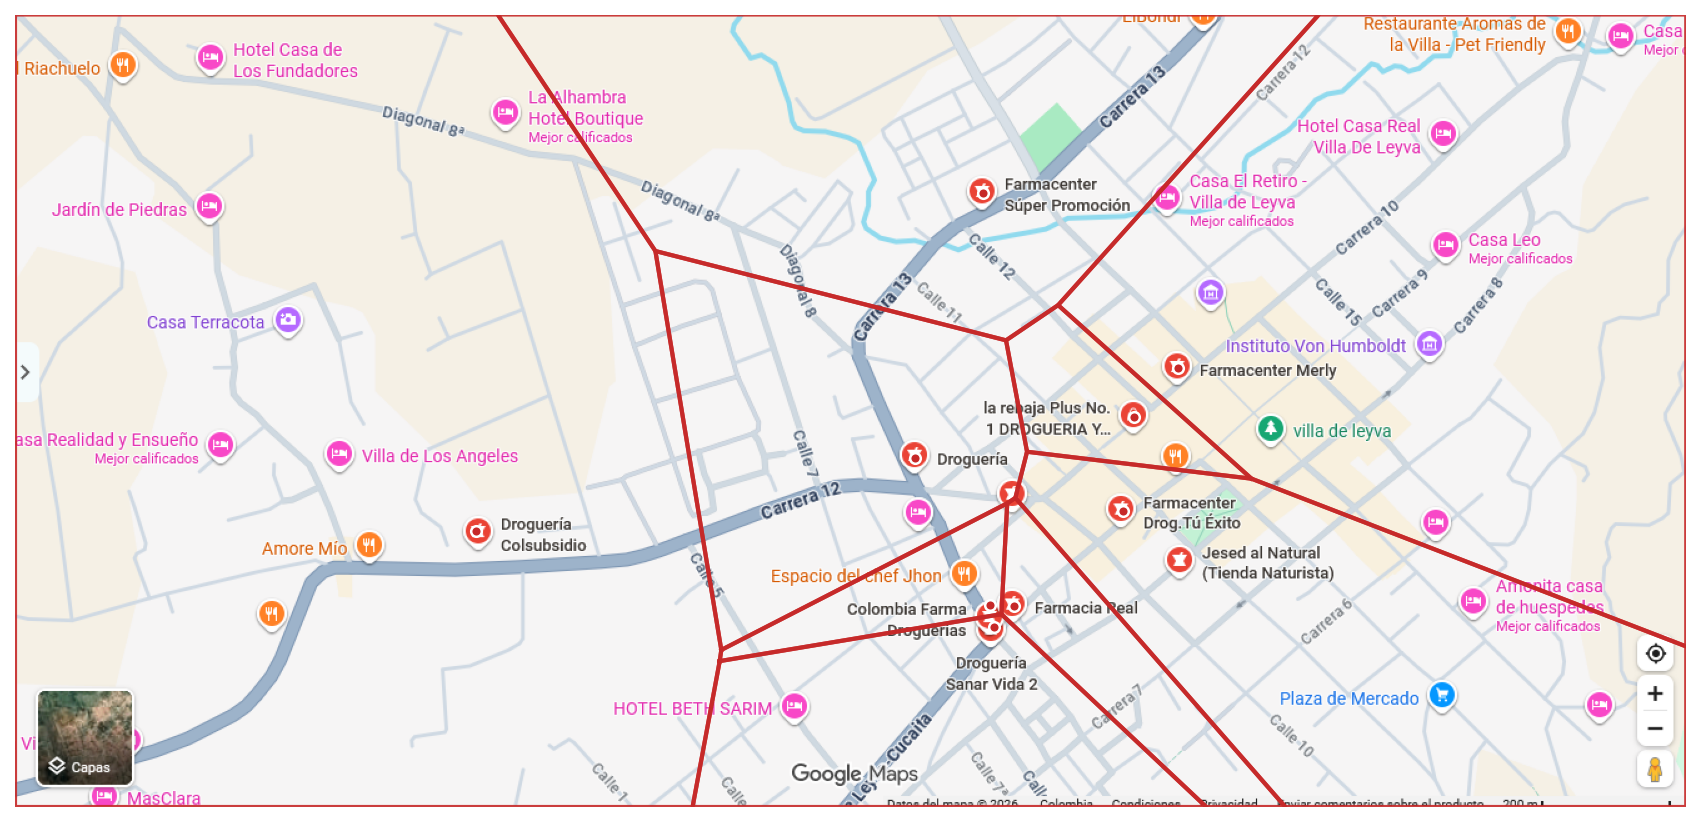

Guardado: mapa_droguerias_voronoi.png


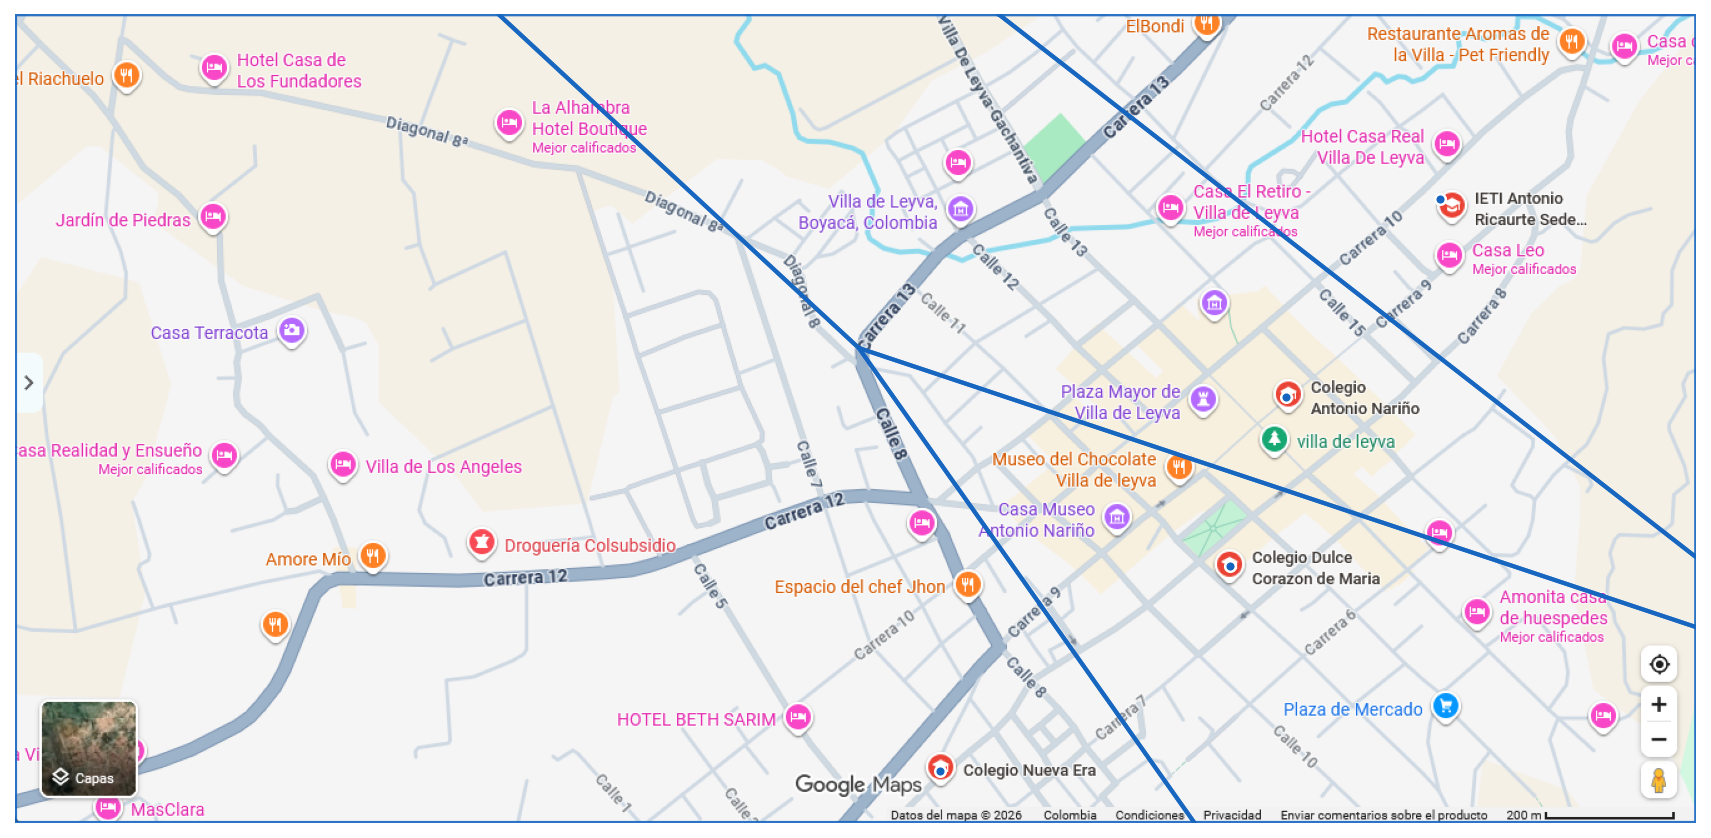

Guardado: mapa_colegios_voronoi.png


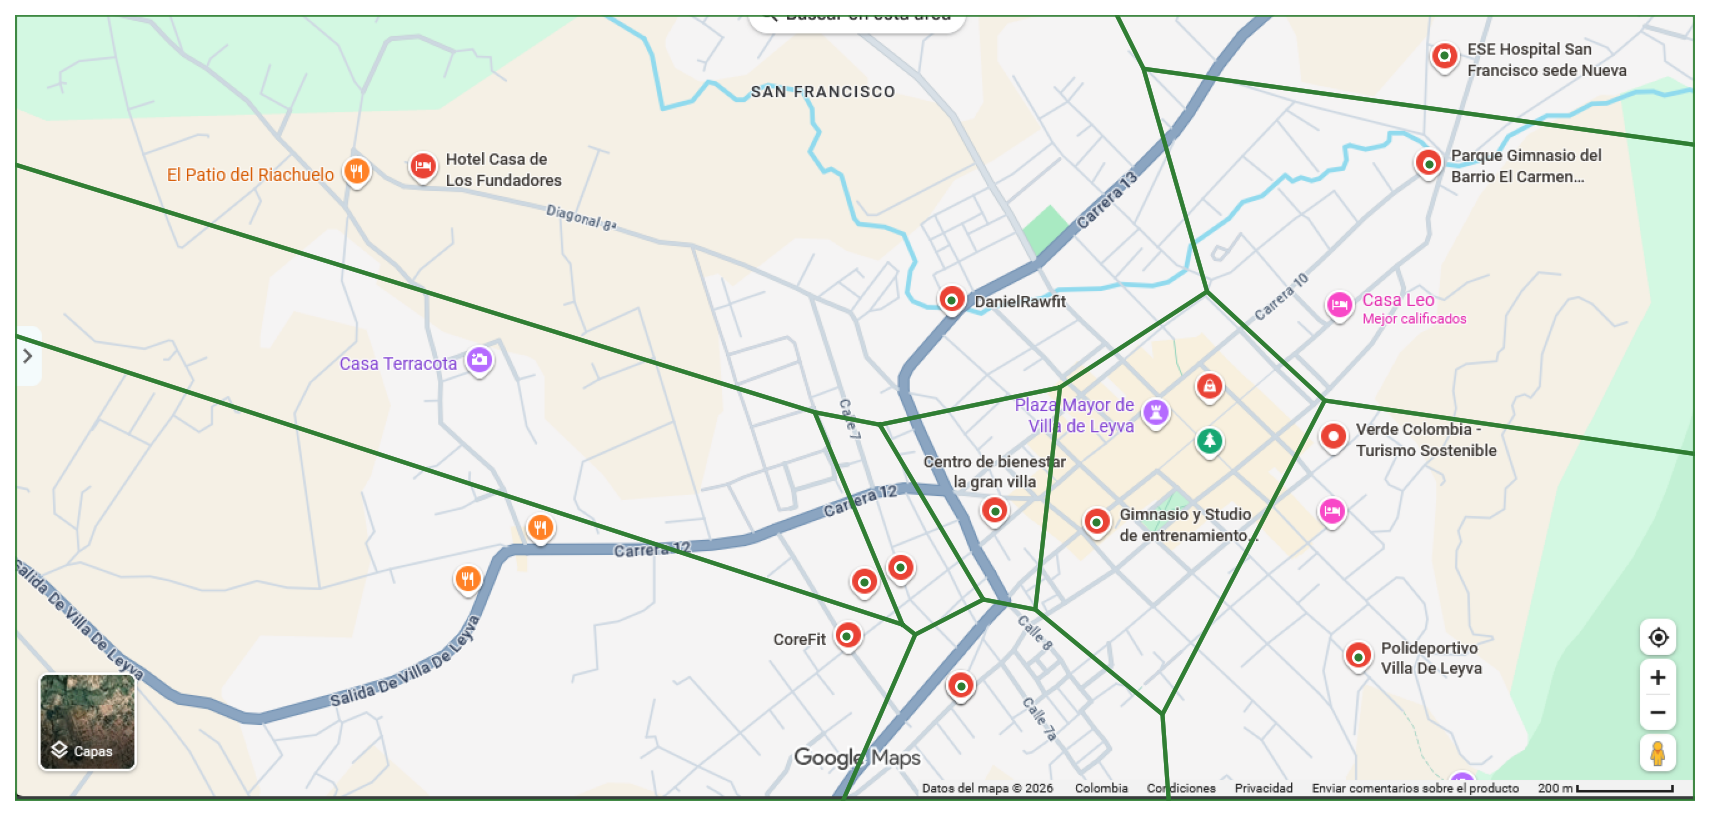

Guardado: mapa_salud_voronoi.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi
from PIL import Image

# ------------------------------------------------------------------
# 1. RUTAS DE TUS IMÁGENES
# ------------------------------------------------------------------
IMG1 = "/content/Captura de pantalla 2026-09-10 222914 (1).png"   # captura de las droguerías
IMG2 = "/content/Captura de pantalla 2026-09-10 223005 (1).png"     # captura de los colegios
IMG3 = "/content/Captura de pantalla 2026-09-10 223113.png"        # captura de salud/bienestar

# ------------------------------------------------------------------
# 2. Coordenadas de píxel (nativas de cada captura)
# ------------------------------------------------------------------
droguerias = {
    "Farmacenter Súper Promoción": (774, 143),
    "Farmacenter Merly": (930, 283),
    "La Rebaja Plus No.1": (895, 322),
    "Droguería (Cra 12)": (720, 355),
    "Farmacenter Drog. Tú Éxito": (886, 397),
    "Droguería Colsubsidio": (369, 413),
    "Colombia Farma Droguerías": (780, 472),
    "Farmacia Real": (799, 473),
    "Droguería Sanar Vida 2": (783, 490),
}

colegios = {
    "IETI Antonio Ricaurte": (1140, 148),
    "Colegio Antonio Nariño": (1017, 306),
    "Colegio Dulce Corazón de María": (972, 441),
    "Colegio Nueva Era": (740, 605),
}

salud = {
    "ESE Hospital San Francisco": (1143, 32),
    "Parque Gimnasio B. El Carmen": (1131, 119),
    "DanielRawfit (gimnasio)": (749, 228),
    "Centro de bienestar la gran villa": (784, 397),
    "Gimnasio y Studio de entrenamiento": (865, 406),
    "Gimnasio (s/n) 1": (679, 454),
    "Gimnasio (s/n) 2": (708, 442),
    "CoreFit": (665, 497),
    "Gimnasio (s/n) 3": (757, 537),
    "Polideportivo Villa de Leyva": (1074, 514),
}


# ------------------------------------------------------------------
# 3. Funciones (recorte de polígonos + Voronoi acotado + overlay)
# ------------------------------------------------------------------
def sutherland_hodgman(subject_polygon, clip_bbox):
    xmin, ymin, xmax, ymax = clip_bbox

    def clip_edge(poly, inside_fn, intersect_fn):
        if not poly:
            return []
        out = []
        n = len(poly)
        for i in range(n):
            cur = poly[i]
            prev = poly[i - 1]
            cur_in = inside_fn(cur)
            prev_in = inside_fn(prev)
            if cur_in:
                if not prev_in:
                    out.append(intersect_fn(prev, cur))
                out.append(cur)
            elif prev_in:
                out.append(intersect_fn(prev, cur))
        return out

    poly = subject_polygon
    poly = clip_edge(poly, lambda p: p[0] >= xmin,
                      lambda a, b: (xmin, a[1] + (b[1] - a[1]) * (xmin - a[0]) / (b[0] - a[0])))
    poly = clip_edge(poly, lambda p: p[0] <= xmax,
                      lambda a, b: (xmax, a[1] + (b[1] - a[1]) * (xmax - a[0]) / (b[0] - a[0])))
    poly = clip_edge(poly, lambda p: p[1] >= ymin,
                      lambda a, b: (a[0] + (b[0] - a[0]) * (ymin - a[1]) / (b[1] - a[1]), ymin))
    poly = clip_edge(poly, lambda p: p[1] <= ymax,
                      lambda a, b: (a[0] + (b[0] - a[0]) * (ymax - a[1]) / (b[1] - a[1]), ymax))
    return poly


def bounded_voronoi(points, bbox):
    """Voronoi acotado: se agregan puntos ficticios lejanos en círculo para
    que ninguna región real quede abierta antes de recortarla al bbox."""
    pts = np.array(points)
    cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
    diag = np.hypot(bbox[2] - bbox[0], bbox[3] - bbox[1])
    R = diag * 8
    angles = np.linspace(0, 2 * np.pi, 24, endpoint=False)
    dummies = np.column_stack([cx + R * np.cos(angles), cy + R * np.sin(angles)])
    all_pts = np.vstack([pts, dummies])
    vor = Voronoi(all_pts)

    polygons = []
    for i in range(len(pts)):
        region_index = vor.point_region[i]
        region = vor.regions[region_index]
        if -1 in region or len(region) == 0:
            polygons.append([])
            continue
        poly = [tuple(vor.vertices[v]) for v in region]
        polygons.append(sutherland_hodgman(poly, bbox))
    return polygons


def overlay(img_path, points_dict, out_path, color):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    bbox = (0, 0, w, h)

    names = list(points_dict.keys())
    coords = list(points_dict.values())
    polygons = bounded_voronoi(coords, bbox)

    fig, ax = plt.subplots(figsize=(w / 120, h / 120), dpi=150)
    ax.imshow(np.array(img))

    for poly in polygons:
        if len(poly) >= 3:
            xs = [p[0] for p in poly] + [poly[0][0]]
            ys = [p[1] for p in poly] + [poly[0][1]]
            ax.plot(xs, ys, color=color, linewidth=2.0, alpha=0.9, zorder=3)

    xs_pts = [c[0] for c in coords]
    ys_pts = [c[1] for c in coords]
    ax.scatter(xs_pts, ys_pts, s=26, facecolor=color, edgecolor="white", linewidth=1.2, zorder=4)

    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(out_path, dpi=150, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print(f"Guardado: {out_path}")


# ------------------------------------------------------------------
# 4. Ejecutar
# ------------------------------------------------------------------
overlay(IMG1, droguerias, "mapa_droguerias_voronoi.png", "#c62828")
overlay(IMG2, colegios, "mapa_colegios_voronoi.png", "#1565c0")
overlay(IMG3, salud, "mapa_salud_voronoi.png", "#2e7d32")